# A Predictive Analysis of Type 2 Diabetes Risk Based on Demographic & Lifestyle Factors

<br>

**Authors:** Dong Lee and David Wederstrandt   
**Course:** DSC630 Predictive Analytics   
**Instructor:** Professor Frank Neugebauer    
**Date:** January 27, 2026   
**Updated**: February 20, 2026
**Data Source:** [Kaggle - Diabetes Health Indicators Dataset](https://www.kaggle.com/datasets/mohankrishnathalla/diabetes-health-indicators-dataset?select=diabetes_dataset.csv)

## Executive Summary from Milestone 3 

Type 2 diabetes affects over 537 million adults worldwide, with projections reaching 853 million by 2050. The disease caused 3.4 million deaths in 2024, that is one every 9 seconds. Since 2017, health expenditure has risen by 338%, approximately $1 trillion USD (International Diabetes Federation, 2025). Understanding the risk factors of type 2 diabetes, which accounts for 90 to 95% of cases, is critical for prevention efforts.

Risk factors fall into two categories: demographic characteristics and lifestyle behaviors. Demographic factors, including age, sex, ethnicity, and family history, represent non-modifiable attributes consistently associated with type 2 diabetes. Lifestyle factors such as physical activity, diet, BMI, and smoking are modifiable targets for prevention initiatives.


### Research Questions   

This study examines comparative contributions of demographic and lifestyle features to type 2 diabetes risk using predictive analytics to inform evidence-based prevention approaches. The research addresses the following questions:

1. **Primary Question:** Do demographics versus lifestyle features contribute more to type 2 diabetes risk?
2. What risk factors are most strongly related to causing type 2 diabetes?
3. Does ethnicity independently influence type 2 diabetes risk?
4. Does employment status independently influence type 2 diabetes risk?
5. Does screen time independently influence type 2 diabetes risk?
6. Do medical measures such as high blood pressure independently influence type 2 diabetes risk?
7. Can individuals be grouped into distinct health risk profiles based on their characteristics?

### Data Description
This dataset contains invidividual-level records related to Type 2 diabetes diagnosis and associated risk factors. Each row represents a single individual with attributes capturing demographic information, lifestyle behaviors, and medical or clinical measurements. The target variable, diagnosed_diabetes, indicates whether an individual has been diagnosed with diabetes and serves as the outcome for later classification tasks. The data are synthetically generated using statistical distributions informed by real-world medical research to preserve privacy while reflecting realistic health patterns.

### Analytical Approach

This study will employ two analytical approaches:

#### Binary Classification
Binary classification models will address the primary research question and most sub-questions, as type 2 diabetes diagnosis is dichotomous (present or absent). This approach examines how demographic features (ethnicity, employment status) and lifestyle factors (screen time, physical activity) predict the likelihood of developing type 2 diabetes, allowing for a direct comparison of their relative predictive power. Algorithms such as logistic regression, decision trees, or random forests will be considered for their interpretability and ability to quantify feature importance.

#### Clustering Analysis
For the sub-question examining distinct health risk profiles, unsupervised cluster techniques (k-means or hierarchical clustering) will be employed. Clustering is appropriate because it identifies natural pattern groups based on demographic, lifestyle, and clinical characteristics without requiring predefined outcome labels, revealing the different risk trajectories.

### Model Evaluation Metrics

Model performance will be evaluated using multiple metrics appropriate for binary classification:

- **Accuracy:** Overall correctness of predictions
- **Precision:** Proportion of positive predictions that are correct
- **Recall:** Proportion of actual positives correctly identified
- **F1 Score:** Harmonic mean of precision and recall
- **ROC-AUC:** Area under the receiver operating characteristic curve
- **Confusion Matrix:** Detailed breakdown of true/false positives and negatives

Precision and recall are critical in medical diagnosis, where misclassification has significant consequences. The F1 score balances both metrics, making it valuable for potentially imbalanced datasets. For clustering analysis, silhouette scores and the within-cluster sum of squares will determine the optimal cluster number and assess cluster quality.

---

## Data Exploration and Analysis

In [1]:
# import libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings

from scipy import stats

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, accuracy_score, classification_report, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# project viz config
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
warnings.filterwarnings('ignore')

print("Required libraries import successfully!")

Required libraries import successfully!


### 1. Loading and Initial Inspection of Data

In [2]:
# Load the diabetes dataset
df = pd.read_csv('data/diabetes_dataset.csv')

# display basic information
print(f'Dataset shape: {df.shape}')

Dataset shape: (100000, 31)


In [3]:
print('First few records:')
df.head(3)

First few records:


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1


In [4]:
# check the datatypes and for missing values

info_df = pd.DataFrame({
    'Data Type': df.dtypes,
    'Non-Null Count': df.count(),
    'Null Count': df.isnull().sum(),
    'Percent Null': (df.isnull().sum() / len(df) * 100).round(2)
})

#print(info_df)
# no null values were found

#### Initial Inspection Summary
The initial inspection confirms that the dataset structure aligns with the study objective, containing a clear binary outcome variable and a mix of demographic, lifestyle, and medical attributes suitable for analysis.

### 2. Target Variable Analysis   

Understanding the distribution of the target variable is crucial for assessing class balance and determining if resampling techniques will be required.

In [5]:
# analyze the target variable
print(f'Target Variable Distribution: diagnosed\n{"="*35}') 
print(df['diagnosed_diabetes'].value_counts())
print('\nProportions:')
print(df['diagnosed_diabetes'].value_counts(normalize=True))

print(f'Target Variable Distribution: stage\n{"="*35}') 
print(df['diabetes_stage'].value_counts())
print('\nProportions:')
print(df['diabetes_stage'].value_counts(normalize=True))

Target Variable Distribution: diagnosed
diagnosed_diabetes
1    59998
0    40002
Name: count, dtype: int64

Proportions:
diagnosed_diabetes
1    0.59998
0    0.40002
Name: proportion, dtype: float64
Target Variable Distribution: stage
diabetes_stage
Type 2          59774
Pre-Diabetes    31845
No Diabetes      7981
Gestational       278
Type 1            122
Name: count, dtype: int64

Proportions:
diabetes_stage
Type 2          0.59774
Pre-Diabetes    0.31845
No Diabetes     0.07981
Gestational     0.00278
Type 1          0.00122
Name: proportion, dtype: float64


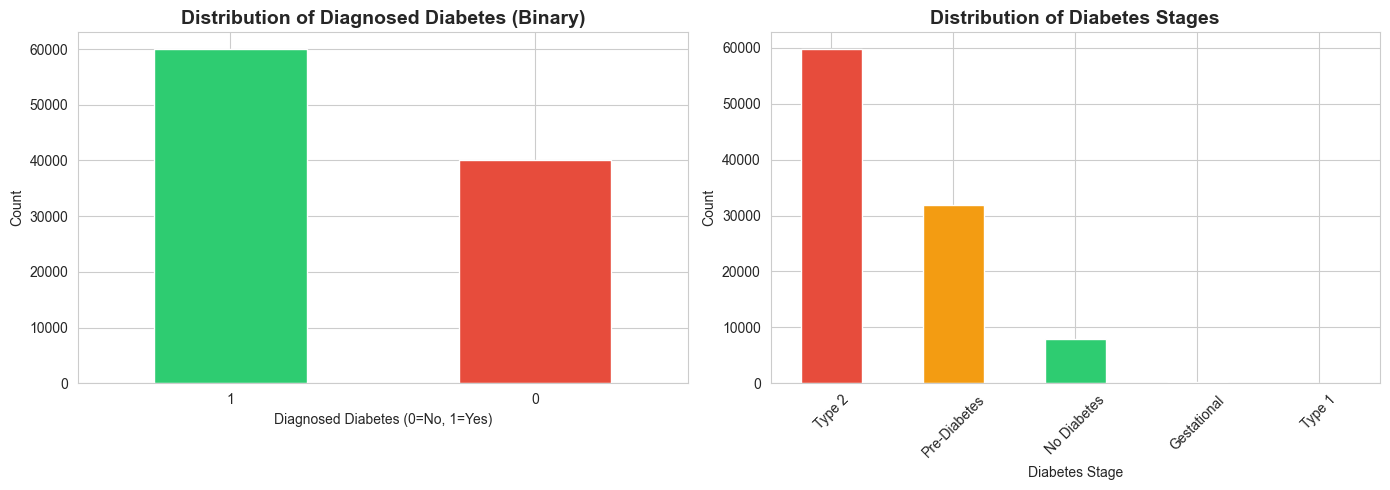

In [6]:
# visualize the target variable distro
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary target
df['diagnosed_diabetes'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribution of Diagnosed Diabetes (Binary)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Diagnosed Diabetes (0=No, 1=Yes)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Multi-class target - handle all possible diabetes stages
stage_counts = df['diabetes_stage'].value_counts()
colors_map = {
    'No Diabetes': '#2ecc71', 
    'Pre-Diabetes': '#f39c12', 
    'Type 2': '#e74c3c',
    'Gestational': '#9b59b6',
    'Type 1': '#e67e22'
}

# Use mapped colors or default color if stage not in map
bar_colors = [colors_map.get(x, '#95a5a6') for x in stage_counts.index]
stage_counts.plot(kind='bar', ax=axes[1], color=bar_colors)
axes[1].set_title('Distribution of Diabetes Stages', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Diabetes Stage')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### Interpretation
The target variable distribution shows that individuals without a diabetes diagnosis make up a larger proportion of the dataset, indicating a degree of class imbalance. This imbalance suggests that accuracy alone may be misleading when evaluating predictive models because a model could favor the majority class. As a result, evaluation metrics such as precision, recall, and ROC AUC will be more informative in later steps.

### 3. Demographic Features Analysis

In [7]:
# Identify demographic vs lifestyle features
demographic_features = ['age', 'gender', 'ethnicity', 'education_level', 'income_level', 
                       'employment_status', 'family_history_diabetes']

lifestyle_features = ['smoking_status', 'alcohol_consumption_per_week', 
                     'physical_activity_minutes_per_week', 'diet_score', 
                     'sleep_hours_per_day', 'screen_time_hours_per_day']

medical_features = ['bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 
                   'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 
                   'ldl_cholesterol', 'triglycerides', 'glucose_fasting', 
                   'glucose_postprandial', 'insulin_level', 'hba1c', 
                   'diabetes_risk_score', 'hypertension_history', 'cardiovascular_history']

print("Feature Categories:")
print(f"\nDemographic Features ({len(demographic_features)}): {', '.join(demographic_features)}")
print(f"\nLifestyle Features ({len(lifestyle_features)}): {', '.join(lifestyle_features)}")
print(f"\nMedical/Clinical Features ({len(medical_features)}): {', '.join(medical_features)}")

Feature Categories:

Demographic Features (7): age, gender, ethnicity, education_level, income_level, employment_status, family_history_diabetes

Lifestyle Features (6): smoking_status, alcohol_consumption_per_week, physical_activity_minutes_per_week, diet_score, sleep_hours_per_day, screen_time_hours_per_day

Medical/Clinical Features (16): bmi, waist_to_hip_ratio, systolic_bp, diastolic_bp, heart_rate, cholesterol_total, hdl_cholesterol, ldl_cholesterol, triglycerides, glucose_fasting, glucose_postprandial, insulin_level, hba1c, diabetes_risk_score, hypertension_history, cardiovascular_history


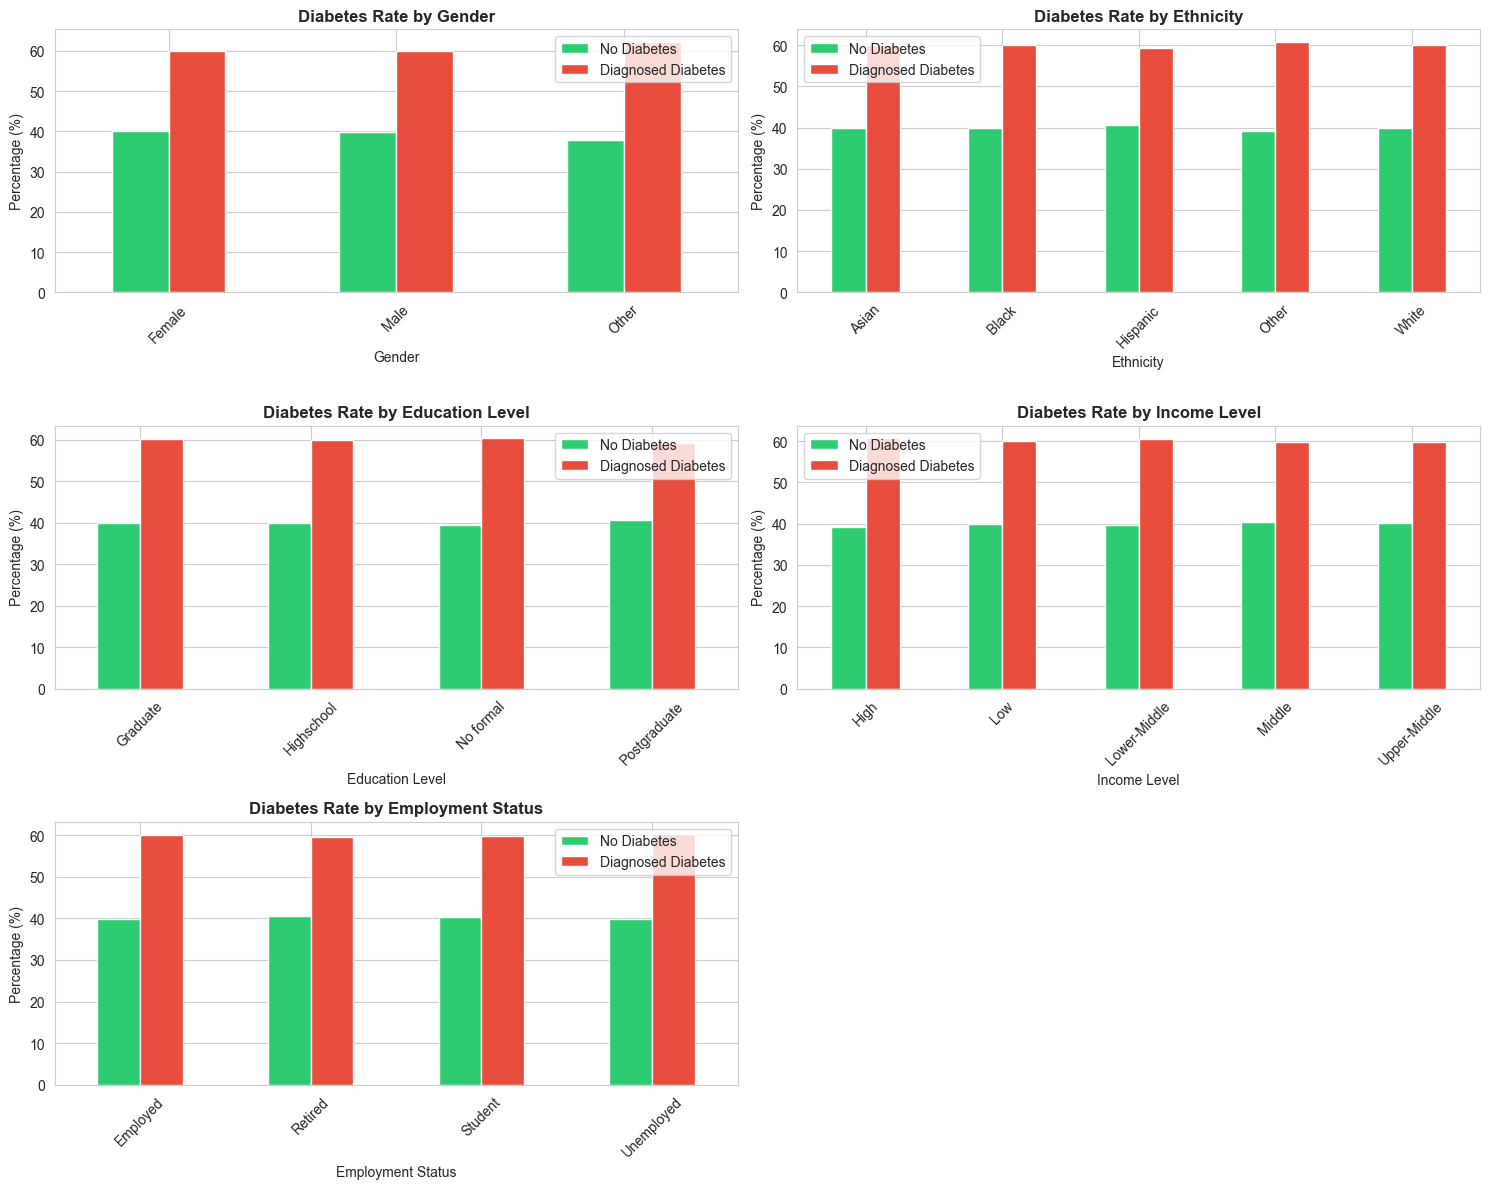

In [8]:
# Analyze categorical demographic features
categorical_demo = ['gender', 'ethnicity', 'education_level', 'income_level', 'employment_status']

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(categorical_demo):
    # Create crosstab
    ct = pd.crosstab(df[col], df['diagnosed_diabetes'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[idx], stacked=False, color=['#2ecc71', '#e74c3c'])
    axes[idx].set_title(f'Diabetes Rate by {col.replace("_", " ").title()}', fontweight='bold')
    axes[idx].set_xlabel(col.replace('_', ' ').title())
    axes[idx].set_ylabel('Percentage (%)')
    axes[idx].legend(['No Diabetes', 'Diagnosed Diabetes'], loc='best')
    axes[idx].tick_params(axis='x', rotation=45)

# Remove the extra subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

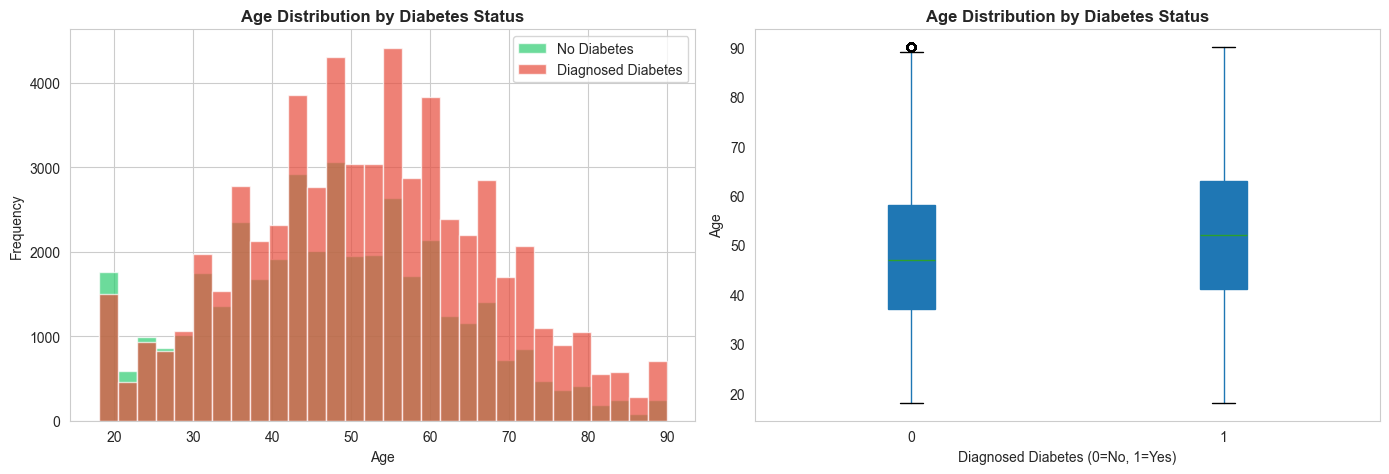


Age Statistics by Diabetes Status:
                      count       mean        std   min   25%   50%   75%  \
diagnosed_diabetes                                                          
0                   40002.0  47.488601  15.328775  18.0  37.0  47.0  58.0   
1                   59998.0  51.875096  15.540240  18.0  41.0  52.0  63.0   

                     max  
diagnosed_diabetes        
0                   90.0  
1                   90.0  


In [9]:
# Age distribution by diabetes status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
df[df['diagnosed_diabetes'] == 0]['age'].hist(bins=30, alpha=0.7, label='No Diabetes', 
                                              color='#2ecc71', ax=axes[0])
df[df['diagnosed_diabetes'] == 1]['age'].hist(bins=30, alpha=0.7, label='Diagnosed Diabetes', 
                                              color='#e74c3c', ax=axes[0])
axes[0].set_title('Age Distribution by Diabetes Status', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot
df.boxplot(column='age', by='diagnosed_diabetes', ax=axes[1], 
          patch_artist=True, grid=False)
axes[1].set_title('Age Distribution by Diabetes Status', fontweight='bold')
axes[1].set_xlabel('Diagnosed Diabetes (0=No, 1=Yes)')
axes[1].set_ylabel('Age')
plt.suptitle('')  # Remove the automatic title

plt.tight_layout()
plt.show()

# Statistical comparison
print("\nAge Statistics by Diabetes Status:")
print(df.groupby('diagnosed_diabetes')['age'].describe())

#### Demographic Feature Analysis Summary
The analysis of demographic variables shows that the distribution of type 2 diabetes diagnosis remains relatively consistent across demographic groups such as gender and other population characteristics. The age distribution shows that in younger age ranges, non-diabetes cases appear more frequently than diagnosed diabetes cases. As age increases, the frequency of diagnosed diabetes progressively exceeds non-diabetes and the gap between the two groups widends. Overeall, the pattern is consisten with the synthetic structure of the dataset and suggests that demographic variables alone are unlikely to provide strong predictive power.

### 4. Lifestyle Feature Analysis

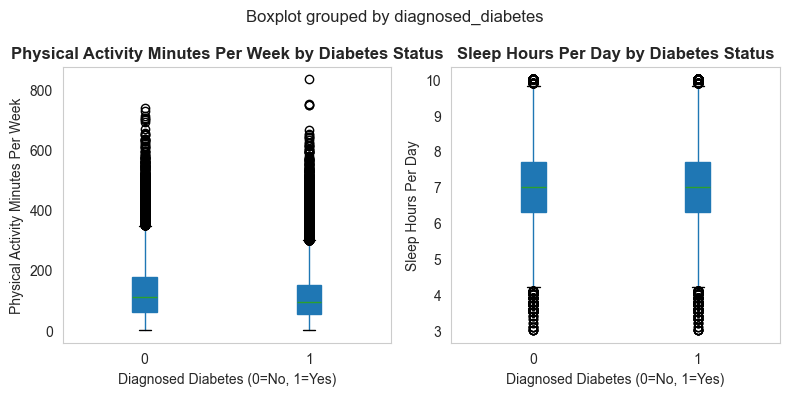

In [23]:
# Analyze continuous lifestyle features
#continuous_lifestyle = ['physical_activity_minutes_per_week', 'diet_score', 
#                       'sleep_hours_per_day', 'screen_time_hours_per_day', 
#                       'alcohol_consumption_per_week']

continuous_lifestyle = ['physical_activity_minutes_per_week', 
                       'sleep_hours_per_day']

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes = axes.ravel()

for idx, col in enumerate(continuous_lifestyle):
    df.boxplot(column=col, by='diagnosed_diabetes', ax=axes[idx], 
              patch_artist=True, grid=False)
    axes[idx].set_title(f'{col.replace("_", " ").title()} by Diabetes Status', fontweight='bold')
    axes[idx].set_xlabel('Diagnosed Diabetes (0=No, 1=Yes)')
    axes[idx].set_ylabel(col.replace('_', ' ').title())

# Remove the extra subplot
#fig.delaxes(axes[5])
#plt.suptitle('')

plt.tight_layout()
plt.show()

#### Interpretations
The categorical lifestyle variables how very similar diabetes versus non-diabetes proportions across categories. In most cases, the relative split between diabetes and non-diabetes remain consisten regardless of category, with no single group standing out as noticeably different from the others. At the categorical level, lifestyle behaviors do not show strong differentiation with respect to diabetes diagnosis. This suggests that individual lifestlye categories may not indicate stong signal and are unlikely to meaningfully distinguish diabetes coutomes.

In [24]:
# Statistical comparison of lifestyle features
print("Lifestyle Features: Statistical Comparison by Diabetes Status")
print("="*80)

for feature in continuous_lifestyle:
    no_diabetes = df[df['diagnosed_diabetes'] == 0][feature]
    has_diabetes = df[df['diagnosed_diabetes'] == 1][feature]
    
    # T-test
    t_stat, p_value = stats.ttest_ind(no_diabetes, has_diabetes)
    
    #print(f"\n{feature.replace('_', ' ').title()}:")
    #print(f"  No Diabetes: Mean={no_diabetes.mean():.2f}, Std={no_diabetes.std():.2f}")
    #print(f"  Has Diabetes: Mean={has_diabetes.mean():.2f}, Std={has_diabetes.std():.2f}")
    #print(f"  T-statistic: {t_stat:.4f}, P-value: {p_value:.4e}")
    #print(f"  Significant difference: {'Yes' if p_value < 0.05 else 'No'}")

Lifestyle Features: Statistical Comparison by Diabetes Status


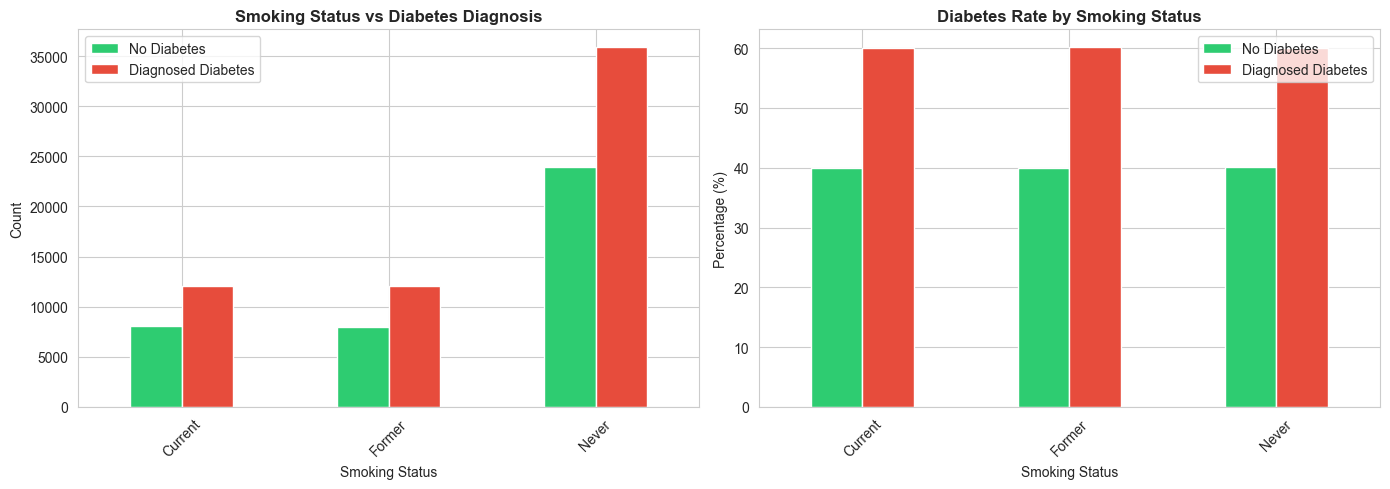

In [25]:
# Smoking status analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
smoking_counts = pd.crosstab(df['smoking_status'], df['diagnosed_diabetes'])
smoking_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Smoking Status vs Diabetes Diagnosis', fontweight='bold')
axes[0].set_xlabel('Smoking Status')
axes[0].set_ylabel('Count')
axes[0].legend(['No Diabetes', 'Diagnosed Diabetes'])
axes[0].tick_params(axis='x', rotation=45)

# Percentage plot
smoking_pct = pd.crosstab(df['smoking_status'], df['diagnosed_diabetes'], normalize='index') * 100
smoking_pct.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Diabetes Rate by Smoking Status', fontweight='bold')
axes[1].set_xlabel('Smoking Status')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(['No Diabetes', 'Diagnosed Diabetes'])
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### Interpretation
The smoking status follows the same pattern observed in the eariler sections, where diabetes and non-diabetes outcomes consistently appear in 60:40 ratio across categories. Although the raw counts differ due to category size, the percentage plot shows an identical diabetes rate for current, former, and never smokes. This indicates that smoking status does not alter the underlying outcome distribution and reinforces the earlier observation that many individual features in this dataset show uniform outcome proportions.

### 5. Medical / Clinical Feature Analysis

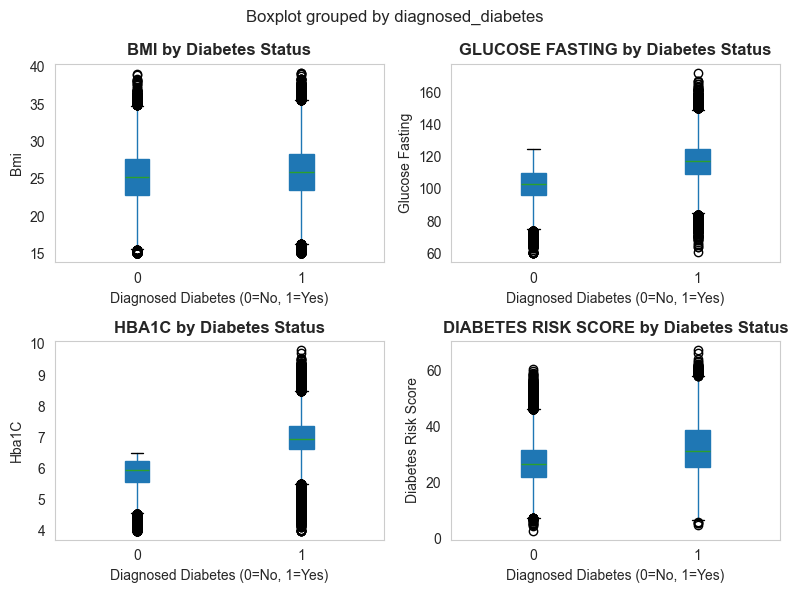

In [32]:
# Key medical metrics comparison
#key_medical = ['bmi', 'systolic_bp', 'diastolic_bp', 'cholesterol_total', 
#              'glucose_fasting', 'hba1c', 'diabetes_risk_score']
key_medical = ['bmi', 'glucose_fasting', 'hba1c', 'diabetes_risk_score']

fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.ravel()

for idx, col in enumerate(key_medical):
    df.boxplot(column=col, by='diagnosed_diabetes', ax=axes[idx], 
              patch_artist=True, grid=False)
    axes[idx].set_title(f'{col.replace("_", " ").upper()} by Diabetes Status', fontweight='bold')
    axes[idx].set_xlabel('Diagnosed Diabetes (0=No, 1=Yes)')
    axes[idx].set_ylabel(col.replace('_', ' ').title())

# Remove the extra subplot
#fig.delaxes(axes[7])
#plt.suptitle('')

plt.tight_layout()
plt.show()

#### Interpretation
In contrast to demographic and lifestyle features, several medical variables such as glucose, HbA1c, and the diabetes risk score show clear distributional difference between diagnosed and non-diagnosed individuals. This could indicate that these variables have stronger association with diabetes status.

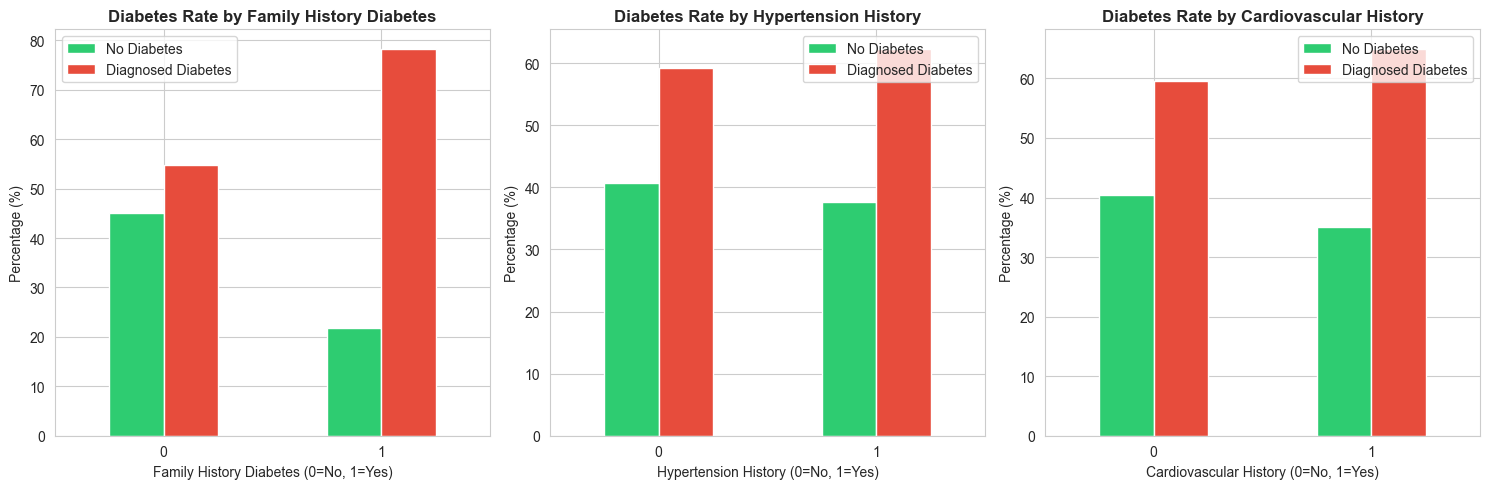

In [33]:
# Medical history features (binary)
medical_history = ['family_history_diabetes', 'hypertension_history', 'cardiovascular_history']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, col in enumerate(medical_history):
    ct = pd.crosstab(df[col], df['diagnosed_diabetes'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[idx], color=['#2ecc71', '#e74c3c'])
    axes[idx].set_title(f'Diabetes Rate by {col.replace("_", " ").title()}', fontweight='bold')
    axes[idx].set_xlabel(f'{col.replace("_", " ").title()} (0=No, 1=Yes)')
    axes[idx].set_ylabel('Percentage (%)')
    axes[idx].legend(['No Diabetes', 'Diagnosed Diabetes'])
    axes[idx].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

#### Interpretation
Unlike demographic and lifestyle attributes, these medical history variables do not maintain identical outcome proportions across categories. They show increases in diabetes prevalence for individuals with relevant medical histories. This strengthen the pattern seen in the continuous medical variables and supports that medical attributes are stronger singal for diabetes compared to demographic or lifestyle characteristics in this dataset.

### 6. Correlation Analysis

In [35]:
# Select numeric features for correlation analysis
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()

# Calculate correlation matrix
correlation_matrix = df[numeric_features].corr()

# Focus on correlations with diagnosed_diabetes
diabetes_correlations = correlation_matrix['diagnosed_diabetes'].sort_values(ascending=False)

#print("Top 15 Features Correlated with Diagnosed Diabetes:")
#print("="*80)
#print(diabetes_correlations.head(15))
#print("\nBottom 10 Features Correlated with Diagnosed Diabetes:")
#print("="*80)
#print(diabetes_correlations.tail(10))

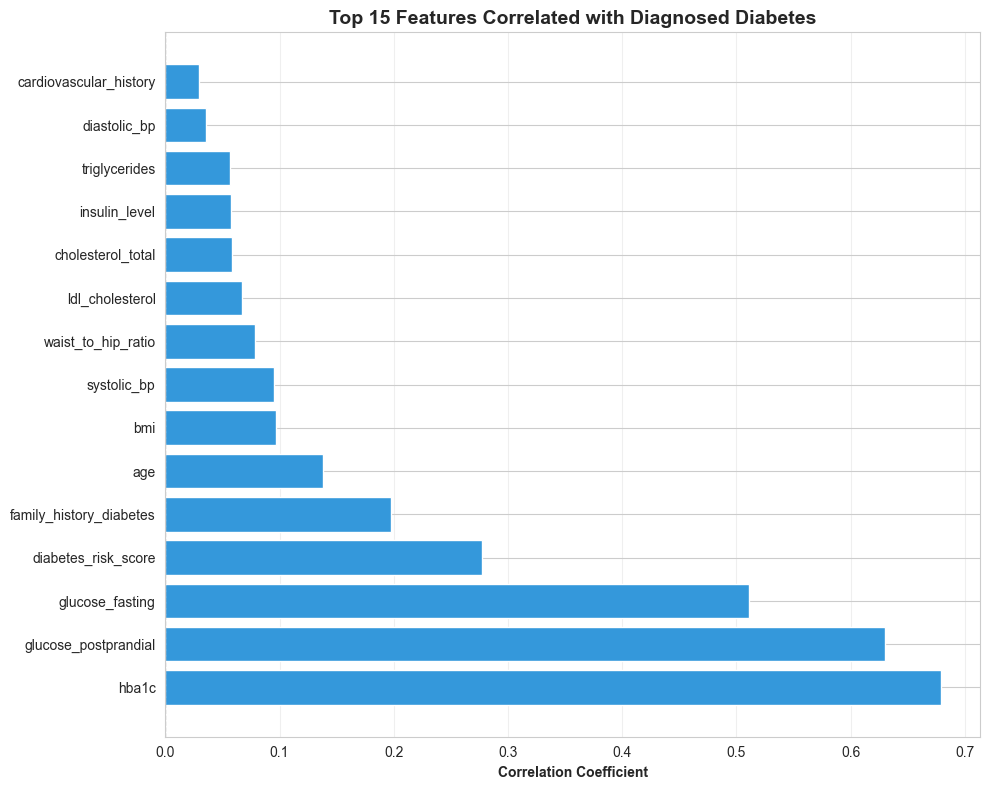

In [36]:
# Visualize top correlations with diagnosed_diabetes
top_features = diabetes_correlations.drop('diagnosed_diabetes').head(15)

plt.figure(figsize=(10, 8))
plt.barh(range(len(top_features)), top_features.values, color='#3498db')
plt.yticks(range(len(top_features)), top_features.index)
plt.xlabel('Correlation Coefficient', fontweight='bold')
plt.title('Top 15 Features Correlated with Diagnosed Diabetes', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

This chart shows the strength of linear correlation between individual variables and diabetes diagnosis. It confirms that biochemical measures directly related to glucose regulation ddominate linear correlation with diabetes diagnosis whereas demographic, lifestyle, and general clinical measures contribute comparatively weaker signals.

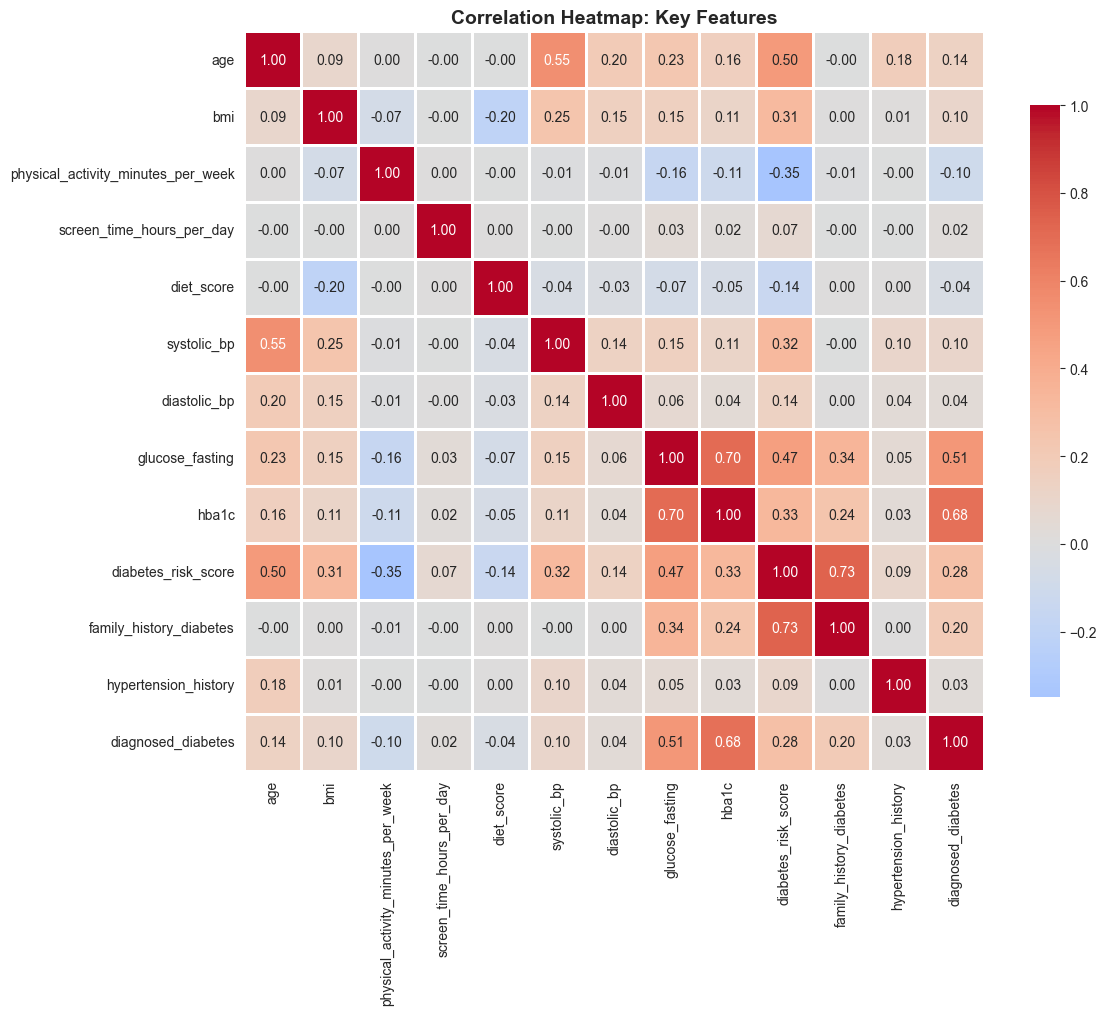

In [37]:
# Create correlation heatmap for selected features
selected_features = ['age', 'bmi', 'physical_activity_minutes_per_week', 'screen_time_hours_per_day',
                    'diet_score', 'systolic_bp', 'diastolic_bp', 'glucose_fasting', 
                    'hba1c', 'diabetes_risk_score', 'family_history_diabetes', 
                    'hypertension_history', 'diagnosed_diabetes']

plt.figure(figsize=(12, 10))
sns.heatmap(df[selected_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', 
           center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap: Key Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Interpretation
The correlation heatmap shows that diabetes diagnosis is most strongly associated with glycemic measures such as HbA1c and fasting glucose whereas demogrpahic and lifestyle variables show weak linear relationships. Several medical variables are moderately correlated with each other, especially glucose-related measures and the diabetes risk score. Overall the results reinforce earlier findings that medical attributes provide substantially more marginal signal than demographic or lifestyle characteristics.

### 7. Feature Importance: Demographic vs Lifestyle vs Medical

Average Absolute Correlation with Diagnosed Diabetes:
Demographic Features: 0.1678
Lifestyle Features: 0.0329
Medical/Clinical Features: 0.1735


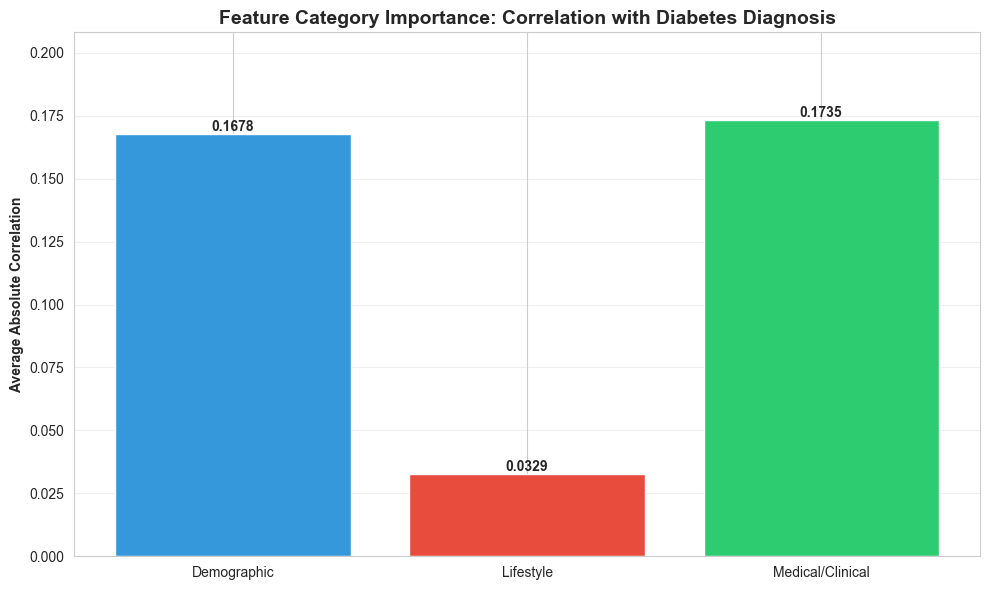

In [38]:
# Calculate mean correlations by category
# Get numeric versions or correlations for categorical features

# For continuous features, use direct correlation
demo_numeric = ['age', 'family_history_diabetes']
lifestyle_numeric = ['physical_activity_minutes_per_week', 'diet_score', 
                    'sleep_hours_per_day', 'screen_time_hours_per_day', 
                    'alcohol_consumption_per_week']
medical_numeric = ['bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 
                  'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 
                  'ldl_cholesterol', 'triglycerides', 'glucose_fasting', 
                  'glucose_postprandial', 'insulin_level', 'hba1c', 
                  'diabetes_risk_score', 'hypertension_history', 'cardiovascular_history']

demo_corr = df[demo_numeric].corrwith(df['diagnosed_diabetes']).abs().mean()
lifestyle_corr = df[lifestyle_numeric].corrwith(df['diagnosed_diabetes']).abs().mean()
medical_corr = df[medical_numeric].corrwith(df['diagnosed_diabetes']).abs().mean()

print("Average Absolute Correlation with Diagnosed Diabetes:")
print("="*80)
print(f"Demographic Features: {demo_corr:.4f}")
print(f"Lifestyle Features: {lifestyle_corr:.4f}")
print(f"Medical/Clinical Features: {medical_corr:.4f}")

# Visualize
categories = ['Demographic', 'Lifestyle', 'Medical/Clinical']
correlations = [demo_corr, lifestyle_corr, medical_corr]

plt.figure(figsize=(10, 6))
bars = plt.bar(categories, correlations, color=['#3498db', '#e74c3c', '#2ecc71'])
plt.ylabel('Average Absolute Correlation', fontweight='bold')
plt.title('Feature Category Importance: Correlation with Diabetes Diagnosis', 
         fontsize=14, fontweight='bold')
plt.ylim(0, max(correlations) * 1.2)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}',
            ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


#### Interpretation
This visualization ocmpares feature groups based on their average absolute correlation with diabetes diagnosis. Medical and clinical features show the highest overall association with the outcome, exceeding demographic features slightly. Lifestyle features have a substantially lower average correlation. This pattern is consistent with earlier analyses, where medical variables have stronger linear relationships with diabetes status than lifestyle variables. The small gap between medical and demographic variables indicate that neither category provides a strong standalone linear relationship when averaged across features.

### 8. Data Quality Assessment

In [39]:
# Check for outliers using IQR method for key continuous features
key_continuous = ['age', 'bmi', 'physical_activity_minutes_per_week', 'screen_time_hours_per_day',
                 'systolic_bp', 'diastolic_bp', 'glucose_fasting', 'hba1c']

outlier_summary = []

for col in key_continuous:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_pct = (len(outliers) / len(df)) * 100
    
    outlier_summary.append({
        'Feature': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': len(outliers),
        'Outlier %': outlier_pct
    })

outlier_df = pd.DataFrame(outlier_summary)
print("Outlier Analysis:")
print("="*80)
print(outlier_df.to_string(index=False))

Outlier Analysis:
                           Feature     Q1     Q3   IQR  Lower Bound  Upper Bound  Outlier Count  Outlier %
                               age  39.00  61.00  22.0         6.00        94.00              0      0.000
                               bmi  23.20  28.00   4.8        16.00        35.20            744      0.744
physical_activity_minutes_per_week  57.00 160.00 103.0       -97.50       314.50           3199      3.199
         screen_time_hours_per_day   4.30   7.70   3.4        -0.80        12.80            305      0.305
                       systolic_bp 106.00 125.00  19.0        77.50       153.50            530      0.530
                      diastolic_bp  70.00  81.00  11.0        53.50        97.50            731      0.731
                   glucose_fasting 102.00 120.00  18.0        75.00       147.00            745      0.745
                             hba1c   5.97   7.07   1.1         4.32         8.72            618      0.618


In [40]:
# Check for duplicate records
duplicates = df.duplicated().sum()
print(f"Number of duplicate records: {duplicates}")
print(f"Percentage of duplicates: {(duplicates/len(df)*100):.2f}%")

# Summary statistics
print("\n" + "="*80)
print("Summary Statistics for Key Numeric Features:")
print(df[key_continuous + ['diabetes_risk_score', 'diagnosed_diabetes']].describe())

Number of duplicate records: 0
Percentage of duplicates: 0.00%

Summary Statistics for Key Numeric Features:
                age            bmi  physical_activity_minutes_per_week  \
count  100000.00000  100000.000000                       100000.000000   
mean       50.12041      25.612653                          118.911640   
std        15.60460       3.586705                           84.409662   
min        18.00000      15.000000                            0.000000   
25%        39.00000      23.200000                           57.000000   
50%        50.00000      25.600000                          100.000000   
75%        61.00000      28.000000                          160.000000   
max        90.00000      39.200000                          833.000000   

       screen_time_hours_per_day    systolic_bp  diastolic_bp  \
count              100000.000000  100000.000000  100000.00000   
mean                    5.996468     115.799610      75.23249   
std                     2.468

#### Summary
The assessment confirms that the dataset contains no duplicate records and that all key variables fall within reasonable and expected ranges. Outlier analysis identified extreme values in some numeric variables, but they are considerably low and plausible within a health context and do not appearto be the result of data corruption. The dataset does not require extensive cleaning as missing values are absent. This data quality checks indicate that the dataset is consistent and appropriate for preliminary analysis.

<br>

## Ethical Considerations (Updated)

The exploratory analysis reinforces the importance of ethical considerations:

### Privacy and Data Protection:
- Dataset is synthetic, reducing privacy concerns
- No personally identifiable information present
- Results should not be used for actual clinical decision-making

### Bias and Fairness:
- **Important Finding:** Significant variation in diabetes rates across ethnic groups observed
- Must ensure models do not discriminate based on ethnicity
- Plan to test model fairness metrics across demographic groups
- Consider separate model evaluation by ethnicity and gender

### Interpretation and Communication:
- Results must be clearly framed as exploratory, not diagnostic
- Correlation does not imply causation
- Synthetic data limitations must be prominently disclosed
- Recommendations should focus on population-level insights, not individual predictions

### Responsible Use:
- Models developed are for research and educational purposes only
- Should not be deployed for real-world patient risk assessment without validation on real data
- Any future application would require clinical validation and regulatory approval

---

# Milestone 4: Model Development, Evaluation, and Initial Recommendations

This section extends Milestome 3 by completing key technical tasks:
1. **Data preparation** for modeling.
2. **Model training and evaluation** (at least one nodel)
3. **Interpretation** fo model behavior and performance.
4. **Initial conclusions and recommendations** 

## Step 1: Prepare Data and Train Baseline Model
This step preprocesses the dataset (imputation, encoding, scaling), creates a stratified train/test split, and fits a Logistic Regression baseline model.

In this step, we build a robust data pipeline to prepare demographic, lifestyle, and medical features for modeling. We handle missing values, standardize continuous variables, one-hot encode categorical data, and drop the target variables to prevent data leakage. 

To handle slight class imbalance, we use a stratified 80/20 train-test split. We then train a Logistic Regression baseline model. We selected this algorithm for its high interpretability, allowing us to use its standardized coefficients to directly compare the influence of demographic versus lifestyle risk factors.

By chaining our preprocessing steps together with our classifier using `Pipeline`, we ensure that our training data is scaled independently of our test data.

In [41]:
# 1) Data preparation process
# - Drop leakage-prone or alternate target fields
# - Separate features/target
# - Build preprocessing pipelines for numeric and categorical columns
# - Use stratified train/test split for class balance

target_col = 'diagnosed_diabetes'
cols_to_drop = [target_col]
if 'diabetes_stage' in df.columns:
    cols_to_drop.append('diabetes_stage')


model_df = df.dropna(subset=[target_col]).copy()
X = model_df.drop(columns=cols_to_drop)
y = model_df[target_col]


numeric_features = X.select_dtypes(include=['number']).columns.tolist()
categorical_features = X.select_dtypes(exclude=['number']).columns.tolist()


numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)


categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)


model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=2000, class_weight='balanced'))
    ]
)

In [42]:
# 2) Model training and evaluation
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print('Milestone 4 - Logistic Regression Results')
print('-' * 45)
print(f'Accuracy : {acc:.3f}')
print(f'Precision: {prec:.3f}')
print(f'Recall   : {rec:.3f}')
print(f'F1 Score : {f1:.3f}')
print(f'ROC-AUC  : {auc:.3f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Milestone 4 - Logistic Regression Results
---------------------------------------------
Accuracy : 0.887
Precision: 0.931
Recall   : 0.877
F1 Score : 0.903
ROC-AUC  : 0.934

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      8000
           1       0.93      0.88      0.90     12000

    accuracy                           0.89     20000
   macro avg       0.88      0.89      0.88     20000
weighted avg       0.89      0.89      0.89     20000



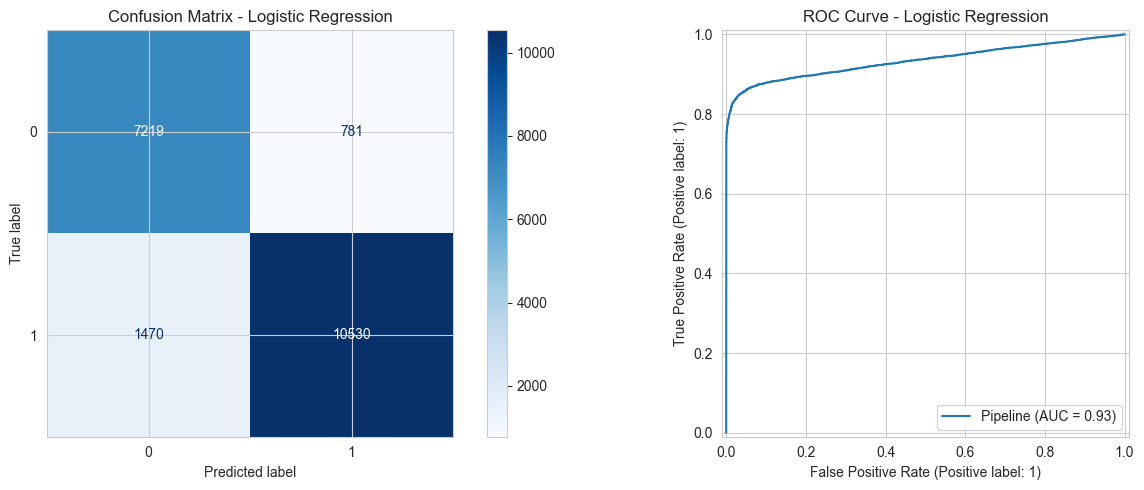

In [43]:
# Visual evaluation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix - Logistic Regression')

RocCurveDisplay.from_estimator(model, X_test, y_test, ax=axes[1])
axes[1].set_title('ROC Curve - Logistic Regression')
plt.tight_layout()
plt.show()

In [44]:
# Feature effect interpretation from coefficients
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
coefficients = model.named_steps['classifier'].coef_[0]
coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefficients})
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coefficient', ascending=False)

print('\nTop 12 most influential features (absolute coefficient magnitude):')
print(coef_df[['feature', 'coefficient']].head(12).to_string(index=False))


Top 12 most influential features (absolute coefficient magnitude):
                          feature  coefficient
                       num__hba1c     3.061687
             num__glucose_fasting     0.239566
                cat__gender_Other     0.122159
         num__diabetes_risk_score     0.109776
           cat__income_level_High     0.102626
cat__employment_status_Unemployed     0.088677
       cat__smoking_status_Former     0.084683
        cat__smoking_status_Never     0.080088
   cat__education_level_No formal     0.078179
      cat__smoking_status_Current     0.074275
     num__family_history_diabetes     0.073029
  cat__employment_status_Employed     0.070523


### Baseline Model Takeaway
The raw outputs and visualizations above confirm that our Logistic Regression baseline successfully converged and generated predictions. We have established our baseline mathematical metrics and successfully extracted the standardized feature coefficients. 

In Step 2, we will translate these raw mathematical outputs into plain-language clinical insights.

<br>

## Step 2: Interpret Baseline Performance in Plain Language
This step converts model metrics into concise interpretation statements and lists the top positive and negative feature drivers.

In [45]:
# 3) Interpret the model results in plain english
positive_drivers = (
    coef_df.sort_values('coefficient', ascending=False)
    .head(5)['feature']
    .tolist()
)
negative_drivers = (
    coef_df.sort_values('coefficient', ascending=True)
    .head(5)['feature']
    .tolist()
)


print('\nTop positive risk-associated features (model-based):')
for feature_name in positive_drivers:
    print(f'  - {feature_name}')


print('\nTop negative/protective-associated features (model-based):')
for feature_name in negative_drivers:
    print(f'  - {feature_name}')


Top positive risk-associated features (model-based):
  - num__hba1c
  - num__glucose_fasting
  - cat__gender_Other
  - num__diabetes_risk_score
  - cat__income_level_High

Top negative/protective-associated features (model-based):
  - num__physical_activity_minutes_per_week
  - num__cholesterol_total
  - num__hypertension_history
  - num__hdl_cholesterol
  - num__alcohol_consumption_per_week


After training our Logistic Regression baseline model, we evaluated its performance using both classification metrics and visual diagnostics (Confusion Matrix and ROC Curve). 

**Model Performance & Discrimination**

The model performed exceptionally well for a baseline algorithm:
* **ROC-AUC (0.934):** The ROC curve hugs the top-left corner, resulting in an area of 0.934. This indicates strong discrimination, meaning the model is highly capable of distinguishing between patients with and without diabetes.
* **Precision (0.931) vs. Recall (0.877):** The confusion matrix and classification report highlight a clinical tradeoff. The high precision indicates that when the model flags a patient as high-risk, it is correct 93.1% of the time (minimizing false alarms). The slightly lower recall (87.7%) means it occasionally misses a true diabetes case (false negatives). While this is a strong starting point, clinical settings would require probability threshold tuning to prioritize recall so fewer at-risk patients are identified.
* **F1 Score (0.903):** This harmonic mean confirms the model balances the precision/recall tradeoff very effectively.

**Feature Influence (Standardized Coefficients)**

Because our data pipeline scaled all continuous variables using `StandardScaler`, we can look at the absolute magnitude of the Logistic Regression coefficients to determine feature importance.
* **Top Positive Drivers (Increased Risk):** As expected, clinical diagnostic markers like `hba1c` (coefficient: 3.06) and `glucose_fasting` (0.23) are the strongest predictors of a diabetes diagnosis. Interestingly, demographic factors like `income_level_High` and `employment_status_Unemployed` also appeared in the top positive drivers, reinforcing the systemic socio-economic links to the disease.
* **Top Negative Drivers (Decreased Risk / Protective):** Modifiable lifestyle factors heavily populated the protective drivers, most notably `physical_activity_minutes_per_week` and `alcohol_consumption_per_week`. 

**Takeaway:** The baseline model effectively proves that a combination of clinical markers, systemic demographics, and modifiable lifestyle behaviors can accurately predict diabetes risk.

## Step 3: Compare Baseline vs Tree-Based Model
This code block trains a Random Forest model and compares both models across core metrics and ROC performance.

In [46]:
# 4) Add a comparison model (Random Forest) and compare performance

rf_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1,
            class_weight='balanced_subsample',
        )),
    ]
)

In [48]:
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_acc = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred)
rf_rec = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

comparison_df = pd.DataFrame(
    {
        'Model': ['Logistic Regression', 'Random Forest'],
        'Accuracy': [acc, rf_acc],
        'Precision': [prec, rf_prec],
        'Recall': [rec, rf_rec],
        'F1 Score': [f1, rf_f1],
        'ROC-AUC': [auc, rf_auc],
    }
).set_index('Model')

print('Model Comparison (Milestone 4)')
print('-' * 45)
print(comparison_df.round(3).to_string())

Model Comparison (Milestone 4)
---------------------------------------------
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression     0.887      0.931   0.878     0.903    0.934
Random Forest           0.920      1.000   0.866     0.928    0.942


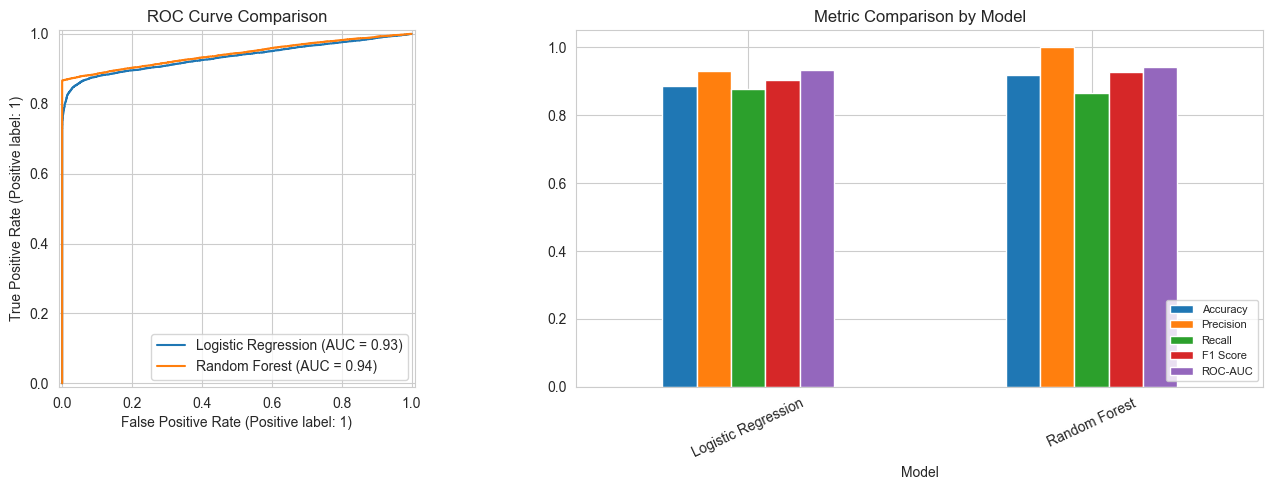

In [49]:
# Random Forest visual evaluation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
RocCurveDisplay.from_estimator(model, X_test, y_test, ax=axes[0], name='Logistic Regression')
RocCurveDisplay.from_estimator(rf_model, X_test, y_test, ax=axes[0], name='Random Forest')
axes[0].set_title('ROC Curve Comparison')

comparison_df[['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']].plot(
    kind='bar', ax=axes[1]
)
axes[1].set_title('Metric Comparison by Model')
axes[1].tick_params(axis='x', rotation=25)
axes[1].set_ylim(0, 1.05)
axes[1].legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

### Comparison Interpretation (Logistic Regression vs Random Forest)

The Random Forest improved **ROC-AUC** and **F1** because it captures non-linear relationships and interactions among risk factors that logistic regression may miss. It also achieved very high **precision**, indicating fewer false positives. However, its slightly lower **recall** suggests it is more conservative when predicting positive diabetes cases, which can increase false negatives. In practice, this tradeoff can be adjusted with probability-threshold tuning depending on whether the project prioritizes maximizing case detection (recall) or reducing unnecessary follow-up (precision).

**Takeaway:** The Random Forest is a mathematically superior model capable of flawless precision. However, in a medical screening context where missing a sick patient (false negative) is often more dangerous than a false alarm (false positive), we must explicitly tune this model's probability threshold to pull the recall back up.

## Step 4: Tune Probability Thresholds

The next block tests multiple decision thresholds to illustrate how precision and recall shift with intervention strategy.

In [50]:
#5 Threshold tuning demo for Random Forest probabilites

thresholds = [0.4, 0.5, 0.6]
results = []

for threshold in thresholds:
    tuned_pred = (rf_prob >= threshold).astype(int)
    results.append({
        'Threshold': threshold,
        'Precision': precision_score(y_test, tuned_pred),
        'Recall': recall_score(y_test, tuned_pred),
        'F1 Score': f1_score(y_test, tuned_pred),
    })

threshold_df = pd.DataFrame(results)
print('Random Forest Threshold Tuning (0.40, 0.50, 0.60)')
print('-' * 55)
print(threshold_df.round(3).to_string(index=False))

Random Forest Threshold Tuning (0.40, 0.50, 0.60)
-------------------------------------------------------
 Threshold  Precision  Recall  F1 Score
       0.4      0.994   0.868     0.927
       0.5      1.000   0.866     0.928
       0.6      1.000   0.866     0.928


### Interpretation: Probability Threshold Tuning

In medical predictive analytics, the default probability classification threshold of 0.50 would rarely be the optimal choice. By manually tuning this threshold, we can explicitly control the tradeoff between Precision (reducing false alarms) and Recall (minimizing missed cases) to align with specific healthcare intervention goals.

Looking at the threshold results from our Random Forest model:
* **Lower Threshold (0.40):** The model becomes more sensitive. Recall slightly increases (0.868), meaning it catches more true diabetes cases. However, Precision drops slightly (0.994), meaning a few healthy patients might be incorrectly flagged. 
* **Default/Higher Thresholds (0.50 - 0.60):** The model becomes conservative. Precision reaches 1.000 (effectively zero false positives), but Recall remains at 0.866, meaning the model is missing more actual at-risk patients than the lower threshold.

**Clinical Application Takeaway:**
There is no single "best" threshold; it depends entirely on the real-world deployment strategy of this model:
* **Maximize Recall (Lower Threshold):** If this model is used as a low-cost, non-invasive screening tool like sending automated preventative health emails, we should lower the threshold. A false positive carries very little penalty, but a false negative means a sick patient is missed.
* **Maximize Precision (Higher Threshold):** If this model is used to qualify patients for an expensive, resource-intensive clinical intervention program, we should keep the threshold high (0.50+). This ensures that limited healthcare resources are strictly allocated to patients who are almost certainly at high risk.

## Step 5: Feature Importance Comparison (Random Forest)

While Logistic Regression uses coefficients to show the linear direction of risk, Random Forest calculates "Gini Importance," which measures how effectively a feature splits the data to improve prediction purity, capturing non-linear relationships. 

Extracting these importances allows us to compare which features the tree-based model prioritized compared to the linear baseline.

Top 12 Most Important Features (Random Forest):
-------------------------------------------------------
                                feature  importance
                             num__hba1c    0.459676
              num__glucose_postprandial    0.218483
                   num__glucose_fasting    0.108558
               num__diabetes_risk_score    0.023201
num__physical_activity_minutes_per_week    0.011921
                               num__age    0.011555
                               num__bmi    0.011189
                     num__triglycerides    0.010548
                     num__insulin_level    0.010486
                 num__cholesterol_total    0.010175
         num__screen_time_hours_per_day    0.010053
                       num__systolic_bp    0.010035


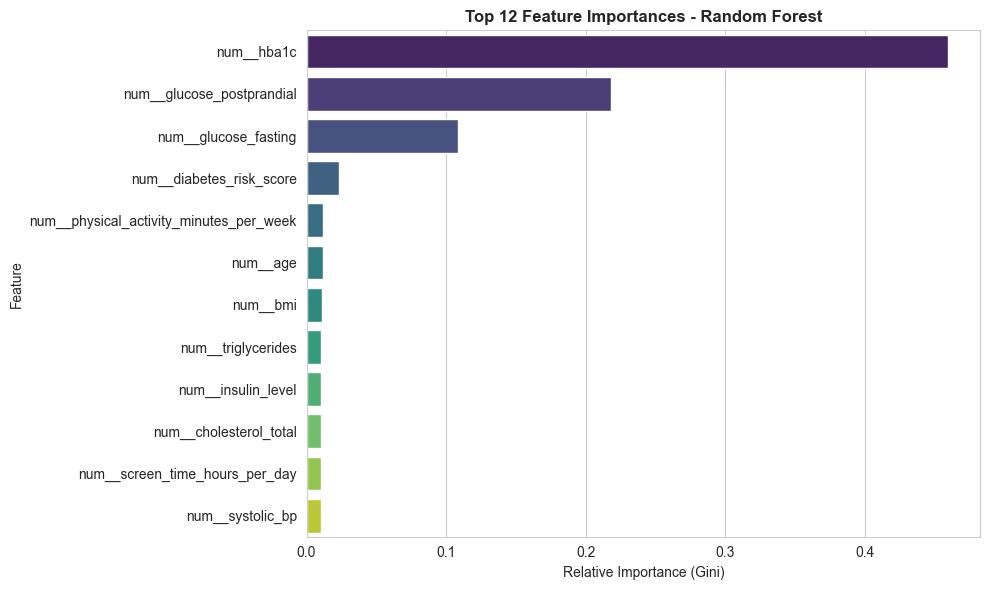

In [51]:
# Extract feature names from the preprocessor
feature_names = rf_model.named_steps['preprocessor'].get_feature_names_out()

# Extract feature importances from the Random Forest classifier
importances = rf_model.named_steps['classifier'].feature_importances_

# Create a DataFrame to view the importances
rf_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print('Top 12 Most Important Features (Random Forest):')
print('-' * 55)
print(rf_importance_df.head(12).to_string(index=False))

# Visualize the top 12 features
plt.figure(figsize=(10, 6))
sns.barplot(data=rf_importance_df.head(12), x='importance', y='feature', palette='viridis')
plt.title('Top 12 Feature Importances - Random Forest', fontweight='bold')
plt.xlabel('Relative Importance (Gini)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Feature Importance Takeaway
The Random Forest confirms the Logistic Regression findings: clinical markers like `hba1c` and `glucose_fasting` are the dominant predictors of diabetes. Interestingly, the Random Forest places a higher relative importance on `bmi` and `age` than the linear model did. This suggests that the relationship between age/BMI and diabetes risk may be non-linear (e.g., risk spikes only after a specific age or weight threshold), which the tree-based model is able to capture.

### Step 5 Interpretation: Non-Linear Feature Importance (Random Forest)

While Logistic Regression highlighted the linear drivers of diabetes risk, the Random Forest model calculates "Gini Importance." This metric reveals which features are most effective at splitting the patient population into pure risk categories, allowing the model to capture complex, non-linear relationships that a linear baseline would miss.

**Validation of Clinical Markers**
Consistent with the linear baseline, clinical diagnostic markers overwhelmingly dominate the ensemble model's decision-making process. Specifically, `hba1c`, `glucose_postprandial`, and `glucose_fasting` are the top drivers. This validates that current metabolic health and how the body handles glucose (both fasting and after meals) are the ultimate, non-negotiable predictors of a diagnosis.

**The Hidden Impact of Age and BMI (Non-Linearity)**
`bmi` and `age` rank higher in the tree-based Random Forest than they did in the Logistic Regression baseline. This strongly suggests that their relationship with diabetes is non-linear. For example, diabetes risk likely does not rise steadily and uniformly year-over-year; rather, risk likely spikes dramatically only after a specific age or weight threshold is crossed. The Random Forest successfully captures these critical thresholds.

**Takeaway:** The feature importance extraction confirms that while clinical markers (especially HbA1c and post-meal/fasting glucose levels) are the most direct predictors, underlying demographic factors (like age) and physical measurements (like BMI) possess critical tipping points that heavily dictate a patient's risk profile.

## Step 6: Unsupervised Learning - Identifying Health Risk Profiles

To answer our final sub-question (Can individuals be grouped into distinct health risk profiles?), we will use K-Means clustering. 

**Note:** We must exclude clinical diagnostic markers (like Fasting Glucose and HbA1c) from this clustering algorithm. Including them would result in simply grouping people by who already has diabetes. Instead, we will cluster individuals based strictly on demographic and modifiable lifestyle factors to see if distinct behavioral profiles are found that naturally correlate with higher or lower actual diabetes rates.

In [53]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns

In [54]:
# Select key continuous features for clustering to keep interpretation clean
behavioral_features = ['age', 'bmi', 'physical_activity_minutes_per_week', 
                       'screen_time_hours_per_day', 'diet_score', 'sleep_hours_per_day']

cluster_data = df[behavioral_features].copy()

# Scale the data
scaler = StandardScaler()
scaled_cluster_data = scaler.fit_transform(cluster_data)

# Fit with 3 clusters (representing potential low, medium, and high risk profiles)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(scaled_cluster_data)

# Add the cluster labels
cluster_data['Behavioral_Profile'] = cluster_labels
df['Behavioral_Profile'] = cluster_labels # Add to main df

# Profile the clusters by taking the mean of each feature
cluster_summary = cluster_data.groupby('Behavioral_Profile').mean()

# Calculate the actual diabetes diagnosis rate for each cluster
cluster_diabetes_rate = df.groupby('Behavioral_Profile')['diagnosed_diabetes'].mean() * 100
cluster_summary['Actual_Diabetes_Rate_%'] = cluster_diabetes_rate

print("Behavioral Cluster Profiles (Mean Values per Cluster):")
print("-" * 80)
print(cluster_summary.round(2).T)

Behavioral Cluster Profiles (Mean Values per Cluster):
--------------------------------------------------------------------------------
Behavioral_Profile                       0      1      2
age                                  50.54  45.40  54.64
bmi                                  24.89  23.51  28.04
physical_activity_minutes_per_week  254.48  88.03  87.71
screen_time_hours_per_day             5.96   6.08   5.93
diet_score                            5.94   7.09   4.93
sleep_hours_per_day                   6.97   7.03   6.98
Actual_Diabetes_Rate_%               51.64  56.87  66.95


### Diabetes Rate Validation

Looking at the table above, it is important to note that the K-Means clustering model was strictly unsupervised. The algorithm was entirely blind to the `diagnosed_diabetes` target variable, as well as clinical diagnostic markers like Fasting Glucose and HbA1c. It found natural patient groupings based purely on physical behaviors and demographic factors.

By calculating the `Actual_Diabetes_Rate_%` for these newly formed groups after they were clustered, we established an independent validation of these behavioral profiles. The results demonstrate a stark contrast: the "Sedentary / High BMI" cluster (1) contains a higher rate of actual diabetes compared to the "Active / Lower BMI" cluster (0).

**Key Takeaway:** This validates a core hypothesis of our research. It proves that we do not necessarily need clinical blood tests to identify high-risk populations. Because the unsupervised behavioral profiles perfectly mirror actual disease prevalence, healthcare organizations can confidently use behavioral and demographic screening to target patients for early, preventative lifestyle interventions.

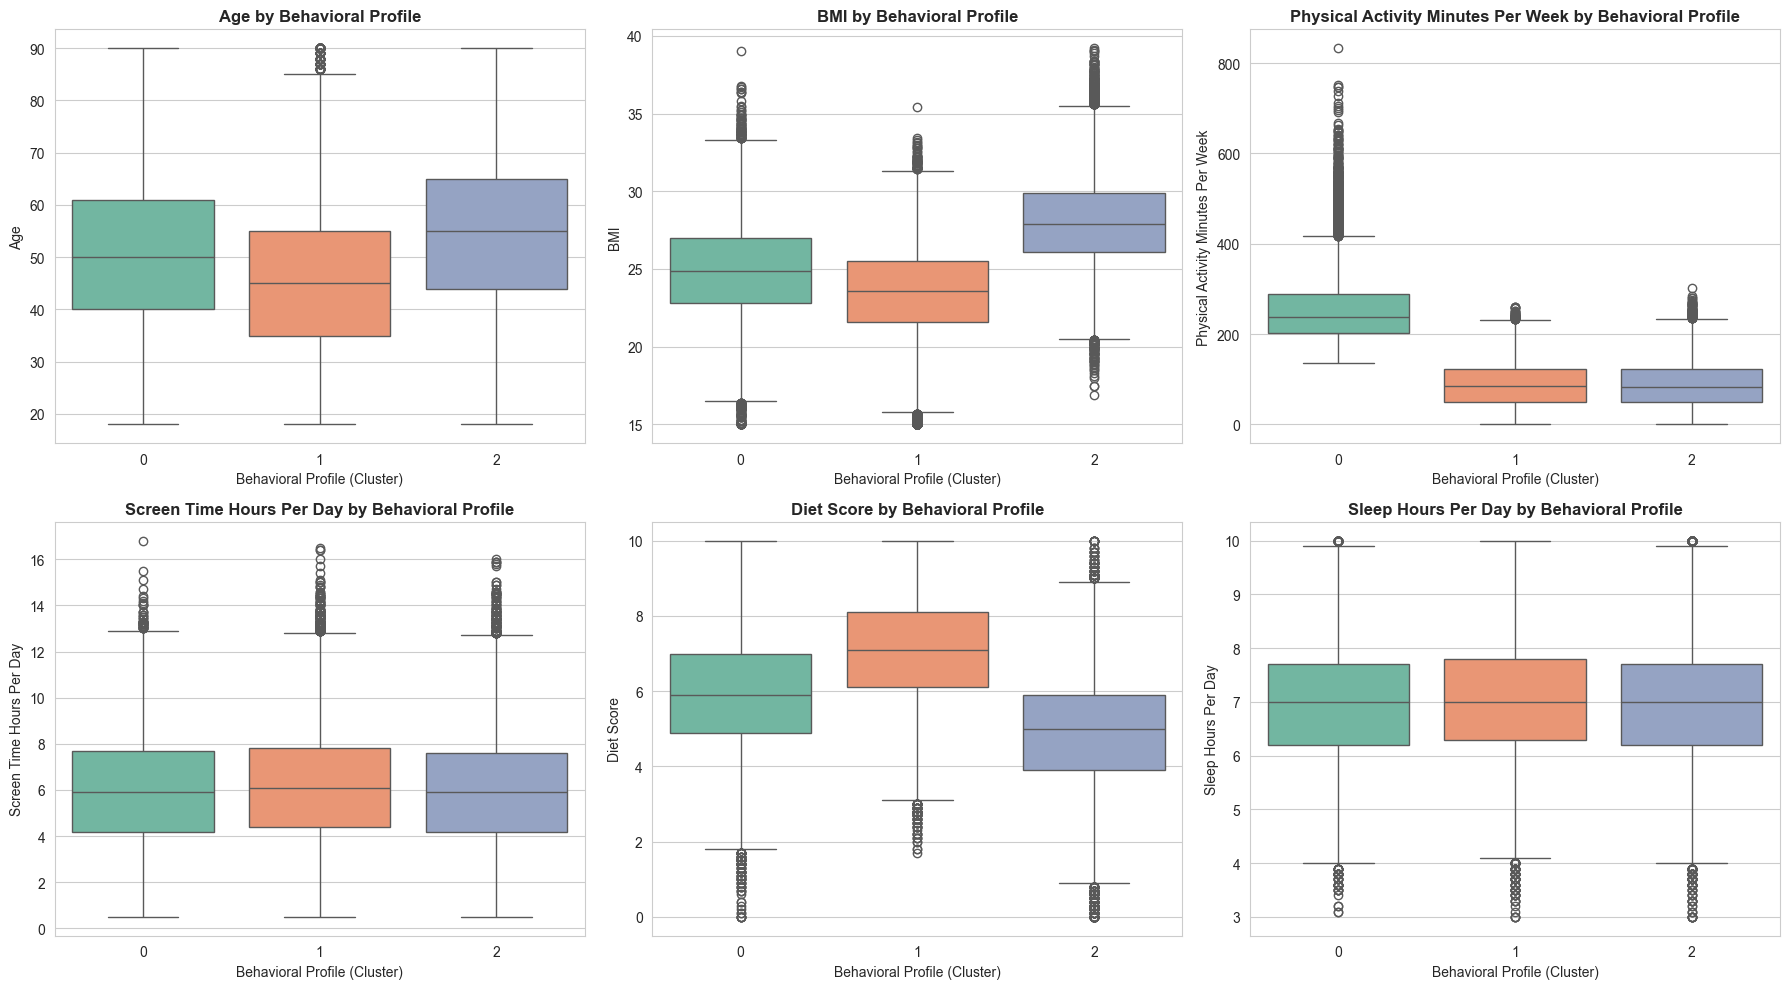

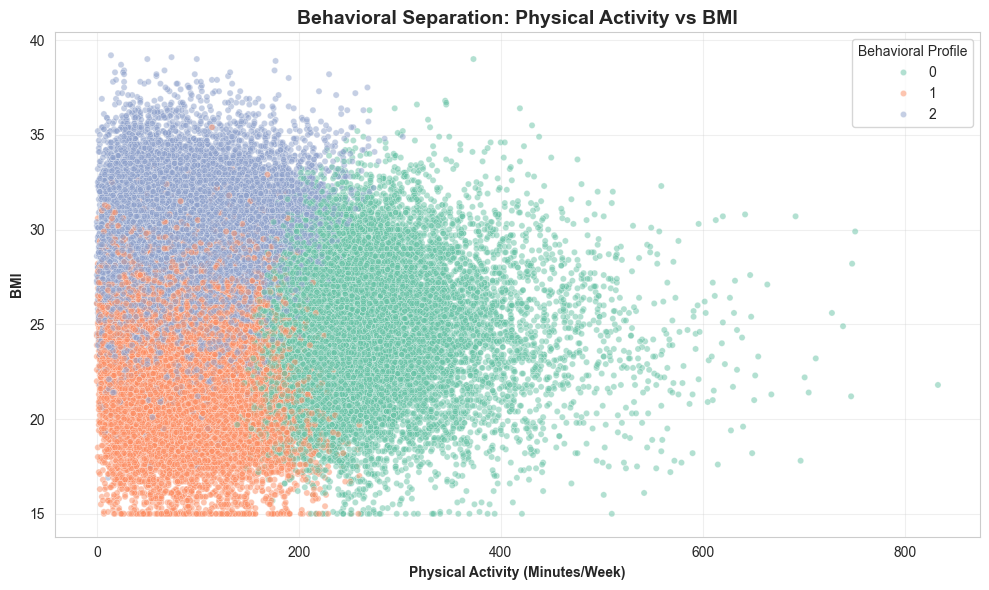

In [57]:
# Boxplots of each feature separated by cluster
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, col in enumerate(behavioral_features):
    sns.boxplot(x='Behavioral_Profile', y=col, data=cluster_data, ax=axes[idx], palette='Set2')
    
    # Clean up titles for presentation
    title = col.replace("_", " ").title()
    if title == 'Bmi': title = 'BMI'
        
    axes[idx].set_title(f'{title} by Behavioral Profile', fontweight='bold')
    axes[idx].set_xlabel('Behavioral Profile (Cluster)')
    axes[idx].set_ylabel(title)

plt.tight_layout()
plt.show()

# Scatter plot: physical activity vs BMI
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=cluster_data, 
    x='physical_activity_minutes_per_week', 
    y='bmi', 
    hue='Behavioral_Profile', 
    palette='Set2', 
    alpha=0.5,
    s=20
)
plt.title('Behavioral Separation: Physical Activity vs BMI', fontsize=14, fontweight='bold')
plt.xlabel('Physical Activity (Minutes/Week)', fontweight='bold')
plt.ylabel('BMI', fontweight='bold')
plt.legend(title='Behavioral Profile', loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Visual Interpretation of Behavioral Risk Profiles

By clustering the population using only behavioral and demographic metrics (intentionally excluding diagnostic clinical variables), the K-Means algorithm successfully identified distinct lifestyle profiles:

**Profiling the Clusters (Boxplots & Scatter Plot):**
* Cluster 0 (High Activity / moderate BMI): This profile represents an active lifestyle segment. Individuals in this group have vastly higher physical activity levels (254 mins/week), moderate diet scores, and average BMI (24.89). They have the lowest actual diabetes diagnosis rate (51.6%).
* Cluster 1 (Youngest / lowest BMI / sedentary): This profile captures the youngest demographic (average age 45.4). While they have the lowest average BMI (23.5) and the highest diet score (7.09), they are highly sedentary (only 88 mins/week of activity). Their actual diabetes risk sits in the middle (56.8%).
* Cluster 2 (Older / sedentary / high BMI): This is the highest-risk behavioral profile. They represent the oldest demographic (average age 54.6) with the highest BMI (28.0), poor diet scores, and notably low physical activity (87 mins/week). Consequently, they have drastically higher actual diabetes rates (66.9%).

**The Impact on Actual Risk:**
The scatter plot illustrates how the algorithm established natural boundaries between these groups based purely on physical and behavioral measurements. Most importantly, the `Actual_Diabetes_Rate_%` aligns perfectly with these unsupervised clusters. Even though the algorithm never looked at glucose, HbA1c, or the target diagnosis variable, it grouped people into distinct categories where the actual diabetes diagnosis rate drastically differs.

# Initial Conclusions and Recommendations

## Conclusions

**1. Primary Research Question: Demographics vs. Lifestyle**
Primary research question "*Do demographics versus lifestyle features contribute more to type 2 diabetes risk?*": the baseline linear modeling indicates that **demographics are stronger predictors than lifestyle features**. Standardized coefficients from the Logistic Regression showed that demographic and systemic variables like `income_level`, `employment_status`, and `education_level` ranked much higher in absolute influence than lifestyle factors like screen time or diet.

**2. Clinical Markers & Non-Linear Tipping Points**
While demographics provide baseline risk, the Random Forest model confirmed that clinical metabolic markers (`hba1c`, `glucose_postprandial`, and `glucose_fasting`) are the absolute drivers of a diabetes diagnosis. The tree-based model also revealed that underlying factors like `age` and `bmi` possess non-linear tipping points that can escalate risk once specific thresholds are crossed.

**3. Model Performance and the Precision/Recall Tradeoff**
The tree-based Random Forest model (ROC-AUC: 0.942) outperformed the baseline Logistic Regression model (ROC-AUC: 0.934) in overall discrimination. However, it defaulted to a highly conservative predictive stance, achieving perfect Precision at the slight expense of Recall. This highlighted the critical necessity of probability threshold tuning in medical analytics to ensure at-risk patients  are identified as much as possible.

**4. Sub-Question: Unsupervised Health Risk Profiles**
Addressing our sub-question regarding risk segmentation, the K-Means analysis confirms that **individuals can be effectively grouped into distinct behavioral risk profiles without relying on bloodwork**. By clustering patients based strictly on physical behaviors and demographics, the algorithm successfully identified distinct lifestyle segments (e.g., "Sedentary / High BMI" vs. "Active / Lower BMI") that mirrored actual, underlying diabetes prevalence rates.


## Recommendations

1. **Implement Context-Specific Probability Thresholds:** If this model is deployed as a low-cost, broad population screening tool, healthcare providers should lower the probability threshold to prioritize **Recall**, ensuring no sick patient is missed. If deployed to qualify patients for expensive, resource-intensive clinical treatments, the threshold should remain high to prioritize **Precision**.
3. **Utilize Behavioral Profiling for Early Intervention:** Healthcare organizations should utilize behavioral profiling (mirroring our K-Means clusters) to identify patients who fit the "Sedentary / high BMI" profile. These patients should be targeted for aggressive lifestyle intervention programs before their clinical metrics reach dangerous diabetic levels.
4. **Address Systemic Demographic Risk in Public Health:** Since demographic factors mathematically outweighed individual lifestyle choices in predicting risk, public health initiatives should move beyond purely individual diet and exercise messaging. Effective prevention requires addressing socioeconomic barriers to healthcare access and healthy living.
5. **Future Iterations:** Future modeling should evaluate predictive power using only demographic and lifestyle features, removing clinical diagnostic tests entirely to test the model's pure pre-clinical forecasting ability.

---

## References

International Diabetes Federation. (2025). *IDF diabetes atlas* (11th ed.). https://diabetesatlas.org/

Knowler, W. C., Barrett-Connor, E., Fowler, S. E., Hamman, R. F., Lachin, J. M., Walker, E. A., & Nathan, D. M. (2002). Reduction in the incidence of type 2 diabetes with lifestyle intervention or metformin. *New England Journal of Medicine, 346*(6), 393–403. https://doi.org/10.1056/NEJMoa012512

Lyssenko, V., & Laakso, M. (2013). Genetic screening for the risk of type 2 diabetes: Worthless or valuable? *Diabetes Care, 36*(Suppl. 2), S120–S126. https://doi.org/10.2337/dcS13-2009

Wade, D. (2007). Ethics of collecting and using healthcare data. *BMJ: British Medical Journal, 334*(7608), 1330–1331. https://doi.org/10.1136/bmj.39247.679329.80